Polyfit vs CubicSpline
Polyfit coeffs: [ 0.0741 -0.5556  1.1005  0.0635]
Polyfit     -> MSE = 0.1693, R^2 = 0.3228
CubicSpline -> MSE = 0.0000, R^2 = 1.0000
Better fit: CubicSpline


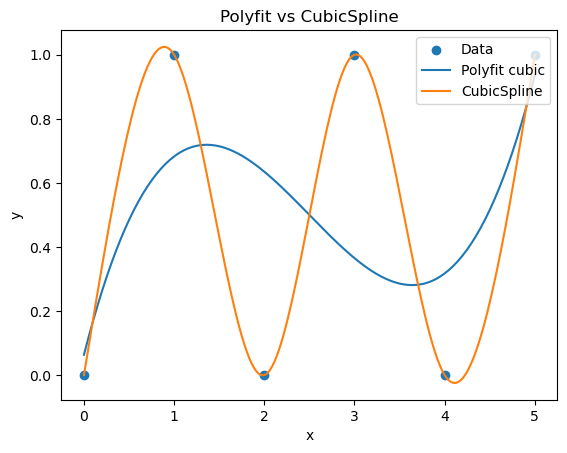

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ChatGPT was used to help organize the comparison
# and check the MSE and R^2 formulas

x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

def mse(y, yhat):
    return np.mean((y - yhat)**2)

def r2(y, yhat):
    return 1 - np.sum((y - yhat)**2) / np.sum((y - np.mean(y))**2)

p = np.polyfit(x, y, 3)
y_poly = np.polyval(p, x)

cs = CubicSpline(x, y, bc_type="natural")
y_spline = cs(x)

print("Polyfit vs CubicSpline")
print(f"Polyfit coeffs: {np.round(p, 4)}")
print(f"Polyfit     -> MSE = {mse(y, y_poly):.4f}, R^2 = {r2(y, y_poly):.4f}")
print(f"CubicSpline -> MSE = {mse(y, y_spline):.4f}, R^2 = {r2(y, y_spline):.4f}")

if mse(y, y_spline) < mse(y, y_poly):
    print("Better fit: CubicSpline")
elif mse(y, y_spline) > mse(y, y_poly):
    print("Better fit: Polyfit")
else:
    print("Both methods fit equally well")

xp = np.linspace(0, 5, 200)

plt.figure()
plt.scatter(x, y, label="Data")
plt.plot(xp, np.polyval(p, xp), label="Polyfit cubic")
plt.plot(xp, cs(xp), label="CubicSpline")
plt.title("Polyfit vs CubicSpline")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()